# DMI - Radar reflectivity over Denmark

This notebook describes how to access and use the zarr-version of the [DMI radar composite](https://opendataapi.dmi.dk/v1/radardata/swagger-ui/index.html) dataset. The dataset includes ten-minute reflectivity over Denmark, which is obtained by the five radars owned by the Danish Meteorologiske Institute (DMI). The `v0.1.1` zarr version of thre dataset covers 2016 to the end of 2024.

The conversion of the radar composite was done by the code hosted on [https://github.com/mlcast-community/mlcast-dataset-DMI/tree/main](https://github.com/mlcast-community/mlcast-dataset-DMI/tree/main)

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import mlcast_datasets

In [2]:
cat = mlcast_datasets.open_catalog()
list(cat.precipitation)

['radklim_hourly',
 'radklim_5_minutes',
 'dmi_10_minutes',
 'it_dpc_sri_5min',
 'uk_metoffice_5min',
 'be_rmi_radclim_mfb_5min']


# DMI 10-min reflectivity

Mlcast catalog contains multiple datasets, hence to call specifically for DMI radar data:

In [3]:
ds = cat.precipitation.dmi_10_minutes.to_dask()
ds

<xarray.Dataset> Size: 14TB
Dimensions:  (time: 517536, y: 1728, x: 1984)
Coordinates:
  * time     (time) datetime64[ns] 4MB 2016-02-29 ... 2025-12-31T23:50:00
  * y        (y) float64 14kB -3.941e+05 -3.936e+05 ... 4.689e+05 4.694e+05
  * x        (x) float64 16kB -4.221e+05 -4.216e+05 ... 5.689e+05 5.694e+05
    lat      (y, x) float64 27MB dask.array<chunksize=(1728, 1984), meta=np.ndarray>
    lon      (y, x) float64 27MB dask.array<chunksize=(1728, 1984), meta=np.ndarray>
Data variables:
    crs      float64 8B ...
    dbz      (time, y, x) float64 14TB dask.array<chunksize=(1, 1728, 1984), meta=np.ndarray>
Attributes:
    Author:                     Thomas Bøvith (tbh@dmi.dk)
    Conventions:                CF-1.6
    consistent_timestep_start:  2016-02-29T00:00:00.000000000
    institution:                Danmarks Meteorologiske Institute (DMI)
    license:                    CC-BY-4.0
    mlcast_created_by:          Ricardo Jara <arjj@dmi.dk>
    mlcast_created_on:          2026-02-24T09:00:17.521323
    mlcast_created_with:        https://github.com/mlcast-community/mlcast-da...
    mlcast_dataset_identifier:  DK-DMI-precipitation
    mlcast_dataset_version:     0.1.1
    title:                      radar-based precipitation

In [4]:
var_name = "dbz"

crs_name = ds[var_name].grid_mapping
data_crs = ccrs.Projection(ds[crs_name].crs_wkt)

/tmp/ipykernel_2515/1860960605.py:15: FutureWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in g.axes.flat:


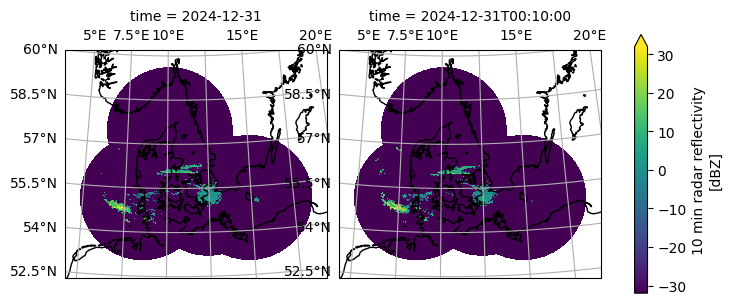

In [5]:
g = (
    ds[var_name]
    .sel(time="2024-12-31")
    .isel(time=slice(None, 2))
    .plot(
        transform=data_crs,
        cmap="viridis",
        add_colorbar=True,
        col="time",
        robust=True,
        subplot_kws=dict(projection=data_crs),
    )
)

for ax in g.axes.flat:
    ax.coastlines()
    ax.gridlines(draw_labels=["top", "left"])